In [2]:
is_causal = True # Set to False for future leakage
run_training = True  # Set to True to run training (takes time)

In [3]:
import pandas as pd
import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_, spectral_norm
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import sys
sys.path.append("../EDAF-Group_6-PV_Forecasting")

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [7]:
pv_data = pd.read_csv("../data/PV_2022_hourly.csv")
weather_data = pd.read_csv("../data/Weather_clean_NEMS.csv")

In [8]:
df_pv = pd.DataFrame(pv_data)
df_weather = pd.DataFrame(weather_data)

In [9]:
df_pv.info()

<class 'pandas.DataFrame'>
RangeIndex: 8758 entries, 0 to 8757
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TimestampInUtc  8758 non-null   str    
 1   pv              8758 non-null   float64
dtypes: float64(1), str(1)
memory usage: 137.0 KB


In [10]:
weather_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    8760 non-null   str    
 1   Temperature                  8760 non-null   float64
 2   Sunshine Duration            8760 non-null   float64
 3   Shortwave Radiation          8760 non-null   float64
 4   Direct Shortwave Radiation   8760 non-null   float64
 5   Diffuse Shortwave Radiation  8760 non-null   float64
 6   Snowfall Amount              8760 non-null   float64
 7   Relative Humidity            8760 non-null   float64
 8   Cloud Cover Total            8760 non-null   float64
dtypes: float64(8), str(1)
memory usage: 616.1 KB


In [11]:
df_pv.head()

,TimestampInUtc,pv
0,2022-01-01 00:00:00,0.0
1,2022-01-01 01:00:00,0.0
2,2022-01-01 02:00:00,0.0
3,2022-01-01 03:00:00,0.0
4,2022-01-01 04:00:00,0.0


In [12]:
df_weather.head()

,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
0,2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0
1,2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0
2,2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
3,2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
4,2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0


In [13]:
df_pv.shape

(8758, 2)

In [14]:
df_weather.shape

(8760, 9)

In [15]:
df_pv[-10:]

,TimestampInUtc,pv
8748,2022-12-31 12:00:00,50.272210
8749,2022-12-31 13:00:00,31.335803
8750,2022-12-31 14:00:00,6.479349
8751,2022-12-31 15:00:00,0.000000
8752,2022-12-31 16:00:00,0.000000
8753,2022-12-31 17:00:00,0.000000
8754,2022-12-31 18:00:00,0.000000
8755,2022-12-31 19:00:00,0.000000
8756,2022-12-31 20:00:00,0.000000
8757,2022-12-31 21:00:00,0.000000


In [16]:
df_pv["TimestampInUtc"] = pd.to_datetime(df_pv["TimestampInUtc"])

last_time = df_pv["TimestampInUtc"].iloc[-1]

new_rows = pd.DataFrame({
    "TimestampInUtc": [
        last_time + pd.Timedelta(hours=1),
        last_time + pd.Timedelta(hours=2)
    ],
    "pv": [0, 0]
})

df_pv = pd.concat([df_pv, new_rows], ignore_index=True)

In [17]:
df_pv[-10:]

,TimestampInUtc,pv
8750,2022-12-31 14:00:00,6.479349
8751,2022-12-31 15:00:00,0.000000
8752,2022-12-31 16:00:00,0.000000
8753,2022-12-31 17:00:00,0.000000
8754,2022-12-31 18:00:00,0.000000
8755,2022-12-31 19:00:00,0.000000
8756,2022-12-31 20:00:00,0.000000
8757,2022-12-31 21:00:00,0.000000
8758,2022-12-31 22:00:00,0.000000
8759,2022-12-31 23:00:00,0.000000


In [62]:
df_pv.shape

(8760, 2)

In [63]:
df_weather.shape

(8760, 9)

In [18]:
df_merged = pd.concat([df_pv, df_weather], axis=1)

In [19]:
df_merged.head()

,TimestampInUtc,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
0,2022-01-01 00:00:00,0.0,2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0
1,2022-01-01 01:00:00,0.0,2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0
2,2022-01-01 02:00:00,0.0,2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
3,2022-01-01 03:00:00,0.0,2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
4,2022-01-01 04:00:00,0.0,2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0


In [20]:
df_merged.iloc[-10:]

,TimestampInUtc,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
8750,2022-12-31 14:00:00,6.479349,2022-12-31 14:00:00,15.597270,40.851063,307.05000,175.559000,131.490980,0.0,64.0,30.000002
8751,2022-12-31 15:00:00,0.000000,2022-12-31 15:00:00,14.687269,40.851063,246.53000,138.154100,108.375900,0.0,64.0,30.000002
8752,2022-12-31 16:00:00,0.000000,2022-12-31 16:00:00,13.027269,47.744680,147.73999,80.121185,67.618805,0.0,68.0,19.200000
8753,2022-12-31 17:00:00,0.000000,2022-12-31 17:00:00,11.937269,33.407090,32.04000,16.751293,15.288709,0.0,68.0,30.000002
8754,2022-12-31 18:00:00,0.000000,2022-12-31 18:00:00,12.117270,0.000000,0.00000,0.000000,0.000000,0.0,61.0,18.600000
8755,2022-12-31 19:00:00,0.000000,2022-12-31 19:00:00,11.847270,0.000000,0.00000,0.000000,0.000000,0.0,59.0,100.000000
8756,2022-12-31 20:00:00,0.000000,2022-12-31 20:00:00,11.437269,0.000000,0.00000,0.000000,0.000000,0.0,58.0,95.000000
8757,2022-12-31 21:00:00,0.000000,2022-12-31 21:00:00,10.897269,0.000000,0.00000,0.000000,0.000000,0.0,58.0,20.000000
8758,2022-12-31 22:00:00,0.000000,2022-12-31 22:00:00,10.407269,0.000000,0.00000,0.000000,0.000000,0.0,59.0,10.000000
8759,2022-12-31 23:00:00,0.000000,2022-12-31 23:00:00,10.557270,0.000000,0.00000,0.000000,0.000000,0.0,58.0,26.000000


In [21]:
df_merged.shape

(8760, 11)

In [22]:
df_merged['timestamp'] = pd.to_datetime(df_merged['timestamp'])
df_merged["hour"] = df_merged["timestamp"].dt.hour
df_merged["day_of_year"] = df_merged["timestamp"].dt.dayofyear
df_merged["month"] = df_merged["timestamp"].dt.month

In [23]:
df_merged.columns

Index(['TimestampInUtc', 'pv', 'timestamp', 'Temperature', 'Sunshine Duration',
       'Shortwave Radiation', 'Direct Shortwave Radiation',
       'Diffuse Shortwave Radiation', 'Snowfall Amount', 'Relative Humidity',
       'Cloud Cover Total', 'hour', 'day_of_year', 'month'],
      dtype='str')

In [24]:
df_merged["hour_sin"]  = np.sin(2 * np.pi * df_merged["hour"] / 24)
df_merged["hour_cos"]  = np.cos(2 * np.pi * df_merged["hour"] / 24)

df_merged["month_sin"] = np.sin(2 * np.pi * df_merged["month"] / 12)
df_merged["month_cos"] = np.cos(2 * np.pi * df_merged["month"] / 12)

df_merged["doy_sin"] = np.sin(2 * np.pi * df_merged["day_of_year"] / 365)
df_merged["doy_cos"] = np.cos(2 * np.pi * df_merged["day_of_year"] / 365)

In [25]:
df_merged.iloc[-744:]

,TimestampInUtc,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total,hour,day_of_year,month,hour_sin,hour_cos,month_sin,month_cos,doy_sin,doy_cos
8016,2022-12-01 00:00:00,0.0,2022-12-01 00:00:00,2.387269,0.0,0.0,0.0,0.0,0.0,90.0,100.0,0,335,12,0.000000,1.000000,-2.449294e-16,1.0,-4.937756e-01,0.869589
8017,2022-12-01 01:00:00,0.0,2022-12-01 01:00:00,2.257269,0.0,0.0,0.0,0.0,0.0,90.0,100.0,1,335,12,0.258819,0.965926,-2.449294e-16,1.0,-4.937756e-01,0.869589
8018,2022-12-01 02:00:00,0.0,2022-12-01 02:00:00,2.057269,0.0,0.0,0.0,0.0,0.0,91.0,100.0,2,335,12,0.500000,0.866025,-2.449294e-16,1.0,-4.937756e-01,0.869589
8019,2022-12-01 03:00:00,0.0,2022-12-01 03:00:00,1.737269,0.0,0.0,0.0,0.0,0.0,93.0,100.0,3,335,12,0.707107,0.707107,-2.449294e-16,1.0,-4.937756e-01,0.869589
8020,2022-12-01 04:00:00,0.0,2022-12-01 04:00:00,1.277269,0.0,0.0,0.0,0.0,0.0,94.0,100.0,4,335,12,0.866025,0.500000,-2.449294e-16,1.0,-4.937756e-01,0.869589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2022-12-31 19:00:00,0.0,2022-12-31 19:00:00,11.847270,0.0,0.0,0.0,0.0,0.0,59.0,100.0,19,365,12,-0.965926,0.258819,-2.449294e-16,1.0,6.432491e-16,1.000000
8756,2022-12-31 20:00:00,0.0,2022-12-31 20:00:00,11.437269,0.0,0.0,0.0,0.0,0.0,58.0,95.0,20,365,12,-0.866025,0.500000,-2.449294e-16,1.0,6.432491e-16,1.000000
8757,2022-12-31 21:00:00,0.0,2022-12-31 21:00:00,10.897269,0.0,0.0,0.0,0.0,0.0,58.0,20.0,21,365,12,-0.707107,0.707107,-2.449294e-16,1.0,6.432491e-16,1.000000
8758,2022-12-31 22:00:00,0.0,2022-12-31 22:00:00,10.407269,0.0,0.0,0.0,0.0,0.0,59.0,10.0,22,365,12,-0.500000,0.866025,-2.449294e-16,1.0,6.432491e-16,1.000000


In [26]:
df_merged.drop(columns=['TimestampInUtc', 'hour', 'day_of_year', 'month'], inplace=True)

In [27]:
import pandas as pd

PV_LAGS = [1, 2, 3, 4, 8, 16, 24, 48, 168]

def add_pv_lags(df: pd.DataFrame, pv_col: str = "pv", lags=PV_LAGS) -> pd.DataFrame:
    df_out = df.copy()

    for lag in lags:
        col_name = f"{pv_col}_lag_{lag}"
        df_out[col_name] = df_out[pv_col].shift(lag)

    # drop the first max(lags) rows (they have NaNs because of shifting)
    max_lag = int(max(lags))
    df_out = df_out.iloc[max_lag:].copy()

    return df_out

# usage (do this after your df is sorted by time index!)
df_model_with_lags = add_pv_lags(df_merged, pv_col="pv", lags=PV_LAGS)

print(df_model_with_lags.columns)
print("Rows before:", len(df_merged), "Rows after:", len(df_model_with_lags))


Index(['pv', 'timestamp', 'Temperature', 'Sunshine Duration',
       'Shortwave Radiation', 'Direct Shortwave Radiation',
       'Diffuse Shortwave Radiation', 'Snowfall Amount', 'Relative Humidity',
       'Cloud Cover Total', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'doy_sin', 'doy_cos', 'pv_lag_1', 'pv_lag_2', 'pv_lag_3', 'pv_lag_4',
       'pv_lag_8', 'pv_lag_16', 'pv_lag_24', 'pv_lag_48', 'pv_lag_168'],
      dtype='str')
Rows before: 8760 Rows after: 8592


In [28]:
df_model_with_lags.head()

,pv,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total,...,doy_cos,pv_lag_1,pv_lag_2,pv_lag_3,pv_lag_4,pv_lag_8,pv_lag_16,pv_lag_24,pv_lag_48,pv_lag_168
168,0.0,2022-01-08 00:00:00,0.867269,0.0,0.0,0.0,0.0,0.0,75.0,58.0,...,0.990532,0.0,0.0,0.0,0.0,0.0,13.881259,0.0,0.0,0.0
169,0.0,2022-01-08 01:00:00,0.817269,0.0,0.0,0.0,0.0,0.0,68.0,80.0,...,0.990532,0.0,0.0,0.0,0.0,0.0,15.000676,0.0,0.0,0.0
170,0.0,2022-01-08 02:00:00,2.247269,0.0,0.0,0.0,0.0,0.0,59.0,100.0,...,0.990532,0.0,0.0,0.0,0.0,0.0,39.493264,0.0,0.0,0.0
171,0.0,2022-01-08 03:00:00,2.917270,0.0,0.0,0.0,0.0,0.0,62.0,100.0,...,0.990532,0.0,0.0,0.0,0.0,0.0,62.488779,0.0,0.0,0.0
172,0.0,2022-01-08 04:00:00,3.347269,0.0,0.0,0.0,0.0,0.0,71.0,100.0,...,0.990532,0.0,0.0,0.0,0.0,0.0,66.906121,0.0,0.0,0.0


Epoch 001/80 | lr=1.00e-03 | train_loss=0.37928 | val_loss=0.29316 | best_val=0.29316
Epoch 002/80 | lr=1.00e-03 | train_loss=0.28912 | val_loss=0.26676 | best_val=0.26676
Epoch 003/80 | lr=1.00e-03 | train_loss=0.25872 | val_loss=0.25869 | best_val=0.25869
Epoch 004/80 | lr=1.00e-03 | train_loss=0.24110 | val_loss=0.26387 | best_val=0.25869
Epoch 005/80 | lr=1.00e-03 | train_loss=0.22884 | val_loss=0.27162 | best_val=0.25869
Epoch 006/80 | lr=1.00e-03 | train_loss=0.22298 | val_loss=0.26893 | best_val=0.25869
LR changed: 1.00e-03 -> 5.00e-04
Epoch 007/80 | lr=5.00e-04 | train_loss=0.21524 | val_loss=0.26545 | best_val=0.25869
Epoch 008/80 | lr=5.00e-04 | train_loss=0.21074 | val_loss=0.25663 | best_val=0.25663
Epoch 009/80 | lr=5.00e-04 | train_loss=0.20506 | val_loss=0.24247 | best_val=0.24247
Epoch 010/80 | lr=5.00e-04 | train_loss=0.20154 | val_loss=0.24600 | best_val=0.24247
Epoch 011/80 | lr=5.00e-04 | train_loss=0.19853 | val_loss=0.25272 | best_val=0.24247
Epoch 012/80 | lr=5.0

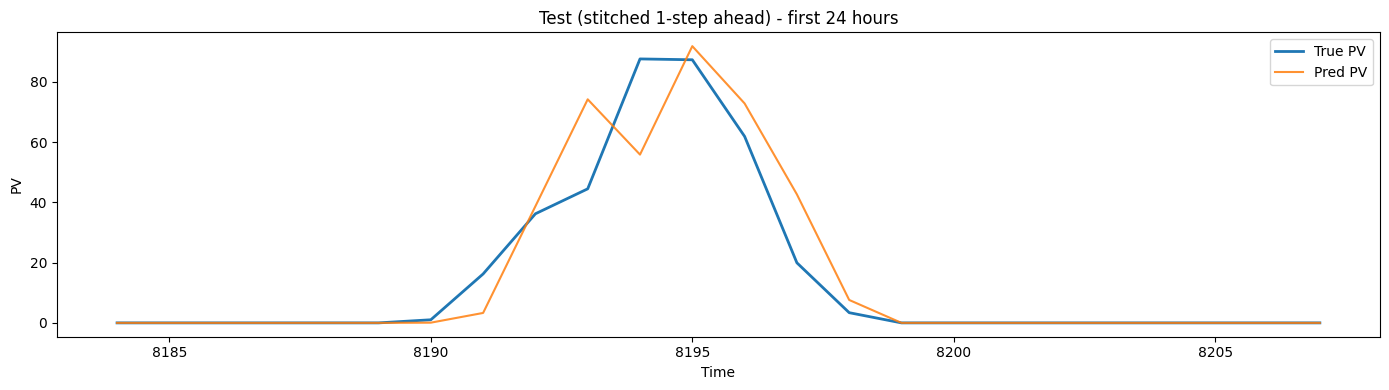

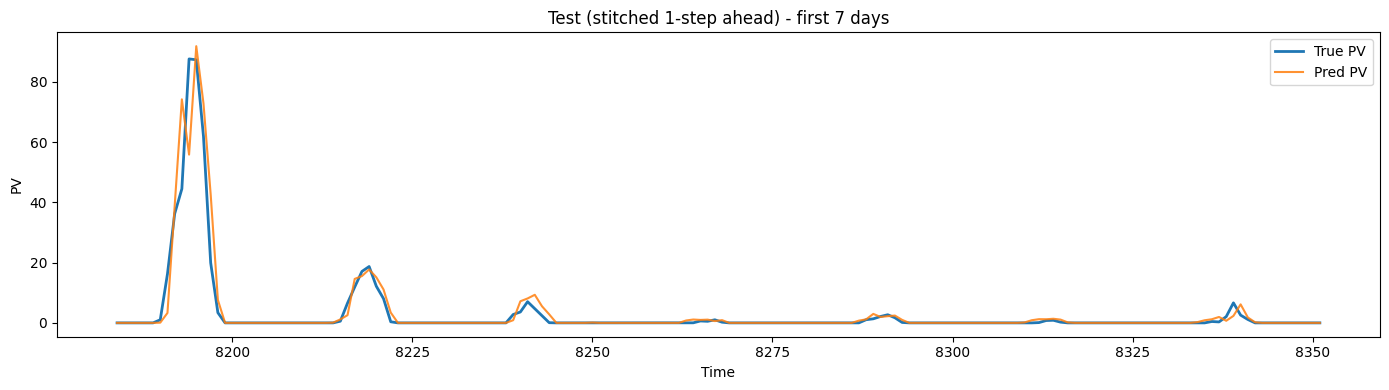

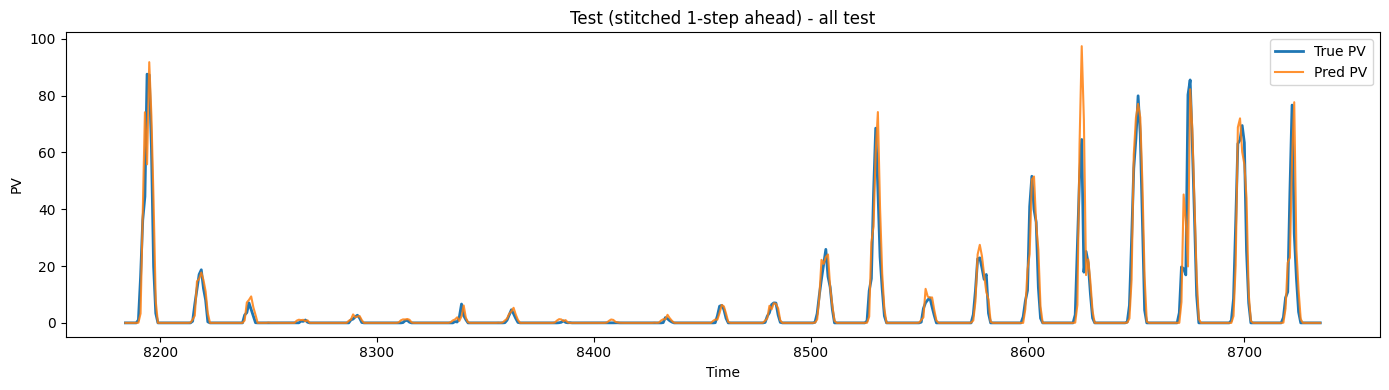

In [29]:
"""
TCN PV forecasting (hourly) — full version v2 (improved overshoot control) with:

Core ideas (already working well for you):
1) Residual objective over persistence baseline (pv_lag_1)
   - model predicts residual in log1p-space:
       r = log1p(pv_future) - log1p(pv_lag_1_at_t0)
   - prediction:
       log1p(pv_hat) = log1p(pv_lag_1) + r_hat  -> expm1 -> pv_hat >= 0

2) Clear-sky proxy feature (radiation-based baseline)
   - fit LinearRegression on TRAIN ONLY: pv ~ radiation + cyclic (+ temp)
   - add as feature pv_clear_proxy

3) Feature engineering (no leakage)
   - daylight flag
   - radiation ratios
   - rolling mean/std on SHIFTED (past only)
   - ramp features (pv_diff_1, sw_diff_1) to reduce ringing/overshoot and sharpen timing

Overshoot fixes added in this v2:
4) Calibrated peak weighting
   - lower PEAK_ALPHA and clip by q99 => fewer max-weight points

5) Asymmetric loss (overprediction penalty)
   - overshoots cost more than undershoots

Plots:
- stitched 1-step ahead over test: first 24 hours, first 7 days, all test

Requirements:
pip install torch numpy pandas scikit-learn matplotlib joblib
"""

from __future__ import annotations

import os
import json
import math
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


# ----------------------------
# Config
# ----------------------------

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TARGET_COL = "pv"

# Base features you already have
CONTINUOUS_FEATURES = [
    "Temperature", "Sunshine Duration", "Shortwave Radiation",
    "Direct Shortwave Radiation", "Diffuse Shortwave Radiation",
    "Snowfall Amount", "Relative Humidity", "Cloud Cover Total",
    "pv_lag_1", "pv_lag_2", "pv_lag_3", "pv_lag_4",
    "pv_lag_8", "pv_lag_16", "pv_lag_24", "pv_lag_48", "pv_lag_168",
]

CYCLIC_FEATURES = [
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "doy_sin", "doy_cos",
]

# Sequence setup (hourly)
LOOKBACK = 168          # 1 week history
HORIZON = 24            # next 24h
TEST_SIZE = 744         # last 31 days

# Validation taken from end of training
VAL_SIZE = 744          # 31 days (inside train)

# Training hyperparams
BATCH_SIZE = 64
EPOCHS = 80
LR = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 1.0

# TCN hyperparams
NUM_CHANNELS = [64, 64, 64, 64, 64]
KERNEL_SIZE = 3
DROPOUT = 0.3           # increased to reduce spikes/overshoot
CAUSAL = True

# Peak-aware weighting (calibrated)
PEAK_ALPHA = 1.5         # lower => less incentive to overshoot
PV_WEIGHT_CLIP_Q = 0.99  # higher quantile => fewer points get max weight

# Asymmetric overprediction penalty
OVERPRED_ALPHA = 1.0     # overshoot penalty factor (0.0 disables)

# “is_day” threshold
DAY_RADIATION_THRESH = 5.0  # adjust if your units differ

# Rolling windows (hours)
ROLL_WINDOWS = [3, 6, 24]

# Saving
OUT_DIR = "./tcn_out"
MODEL_PATH = os.path.join(OUT_DIR, "tcn_pv_full_residual_log1p_v2.pt")
SCALER_X_PATH = os.path.join(OUT_DIR, "scaler_x.joblib")
SCALER_Y_PATH = os.path.join(OUT_DIR, "scaler_y_residual_log1p.joblib")
CLEARSKY_MODEL_PATH = os.path.join(OUT_DIR, "clearsky_lr.joblib")
CONFIG_PATH = os.path.join(OUT_DIR, "config.json")


# ----------------------------
# Utils
# ----------------------------

def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str) -> None:
    if os.path.exists(path) is False:
        os.makedirs(path, exist_ok=True)


def safe_log1p(y: np.ndarray) -> np.ndarray:
    y2 = y.copy()
    y2[y2 < 0] = 0.0
    return np.log1p(y2)


def safe_expm1(y_log: np.ndarray) -> np.ndarray:
    y = np.expm1(y_log)
    y[y < 0] = 0.0
    return y


def current_lr(optimizer: torch.optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


# ----------------------------
# Feature engineering
# ----------------------------

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds engineered features without leaking future information.

    - is_day: based on current Shortwave Radiation
    - ratios: using current radiation components
    - rolling means/std: computed on SHIFTED series (strictly past)
    - ramp features: pv_diff_1 (already past via lags), sw_diff_1 (past via shift)
    """
    out = df.copy()
    eps = 1e-6

    # Daylight indicator
    if "Shortwave Radiation" in out.columns:
        out["is_day"] = (out["Shortwave Radiation"] > DAY_RADIATION_THRESH).astype(float)
    else:
        out["is_day"] = 0.0

    # Radiation ratios / indices
    if (
        ("Shortwave Radiation" in out.columns)
        and ("Direct Shortwave Radiation" in out.columns)
        and ("Diffuse Shortwave Radiation" in out.columns)
    ):
        sw = out["Shortwave Radiation"].to_numpy(dtype=float)
        direct = out["Direct Shortwave Radiation"].to_numpy(dtype=float)
        diffuse = out["Diffuse Shortwave Radiation"].to_numpy(dtype=float)

        out["direct_ratio"] = direct / (sw + eps)
        out["diffuse_ratio"] = diffuse / (sw + eps)
        out["clearness_index"] = direct / (diffuse + eps)
    else:
        out["direct_ratio"] = 0.0
        out["diffuse_ratio"] = 0.0
        out["clearness_index"] = 0.0

    # Rolling stats (strictly past => shift(1))
    if TARGET_COL in out.columns:
        pv_past = out[TARGET_COL].shift(1)
        for w in ROLL_WINDOWS:
            out[f"pv_roll_mean_{w}"] = pv_past.rolling(window=w, min_periods=w).mean()
            out[f"pv_roll_std_{w}"] = pv_past.rolling(window=w, min_periods=w).std()

    if "Shortwave Radiation" in out.columns:
        sw_past = out["Shortwave Radiation"].shift(1)
        for w in ROLL_WINDOWS:
            out[f"sw_roll_mean_{w}"] = sw_past.rolling(window=w, min_periods=w).mean()
            out[f"sw_roll_std_{w}"] = sw_past.rolling(window=w, min_periods=w).std()

    # Ramp features (past-only)
    if ("pv_lag_1" in out.columns) and ("pv_lag_2" in out.columns):
        out["pv_diff_1"] = out["pv_lag_1"] - out["pv_lag_2"]
    else:
        out["pv_diff_1"] = 0.0

    if "Shortwave Radiation" in out.columns:
        out["sw_diff_1"] = out["Shortwave Radiation"].shift(1) - out["Shortwave Radiation"].shift(2)
    else:
        out["sw_diff_1"] = 0.0

    return out


def fit_clearsky_proxy_lr(df_train_only: pd.DataFrame) -> LinearRegression:
    """
    Fit a simple baseline model on TRAIN ONLY.
    Stable and surprisingly effective as a "shape prior".
    """
    proxy_features = [
        "Shortwave Radiation",
        "Direct Shortwave Radiation",
        "Diffuse Shortwave Radiation",
        "hour_sin", "hour_cos",
        "doy_sin", "doy_cos",
        "Temperature",
    ]

    usable = [c for c in proxy_features if c in df_train_only.columns]

    X = df_train_only[usable].to_numpy()
    y = df_train_only[TARGET_COL].to_numpy()

    model = LinearRegression()
    model.fit(X, y)
    model._proxy_cols = usable  # type: ignore[attr-defined]
    return model


def add_clearsky_proxy_feature(df: pd.DataFrame, proxy_model: LinearRegression) -> pd.DataFrame:
    out = df.copy()
    usable = proxy_model._proxy_cols  # type: ignore[attr-defined]
    X = out[usable].to_numpy()
    pred = proxy_model.predict(X)
    pred[pred < 0] = 0.0
    out["pv_clear_proxy"] = pred
    return out


# ----------------------------
# Sequence builder
# ----------------------------

def build_supervised_sequences(
    df: pd.DataFrame,
    feature_cols: List[str],
    residual_target_col: str,
    pv_true_col_for_weight: str,
    lookback: int,
    horizon: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    feat = df[feature_cols].to_numpy()
    y_resid = df[residual_target_col].to_numpy()
    y_pv = df[pv_true_col_for_weight].to_numpy()

    n = len(df)
    last_t = n - horizon

    X_list = []
    y_list = []
    pv_list = []
    t0_list = []

    for t in range(lookback, last_t):
        X_list.append(feat[t - lookback : t, :])
        y_list.append(y_resid[t : t + horizon])
        pv_list.append(y_pv[t : t + horizon])

        if df.index is not None:
            t0_list.append(df.index[t])
        else:
            t0_list.append(t)

    X_out = np.stack(X_list, axis=0)
    y_out = np.stack(y_list, axis=0)
    pv_out = np.stack(pv_list, axis=0)
    t0_out = np.array(t0_list)

    return X_out, y_out, pv_out, t0_out


# ----------------------------
# Dataset (with weights)
# ----------------------------

class SeqDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> None:
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.w = w.astype(np.float32)

    def __len__(self) -> int:
        return int(self.X.shape[0])

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return (
            torch.from_numpy(self.X[idx]),
            torch.from_numpy(self.y[idx]),
            torch.from_numpy(self.w[idx]),
        )


# ----------------------------
# TCN
# ----------------------------

class Chomp1d(nn.Module):
    def __init__(self, chomp_size: int) -> None:
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        dilation: int,
        dropout: float,
        causal: bool,
    ) -> None:
        super().__init__()

        padding = (kernel_size - 1) * dilation

        if causal is True:
            conv_padding = padding
        else:
            conv_padding = padding // 2

        self.conv1 = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=conv_padding,
        )
        self.chomp1 = Chomp1d(padding) if causal is True else nn.Identity()
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=conv_padding,
        )
        self.chomp2 = Chomp1d(padding) if causal is True else nn.Identity()
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.downsample = None
        if in_channels != out_channels:
            self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1)

        self.final_relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        res = x
        if self.downsample is not None:
            res = self.downsample(x)

        return self.final_relu(out + res)


class TCN(nn.Module):
    def __init__(
        self,
        input_size: int,
        output_size: int,
        num_channels: List[int],
        kernel_size: int,
        dropout: float,
        causal: bool,
    ) -> None:
        super().__init__()

        layers: List[nn.Module] = []
        in_ch = input_size
        for i, out_ch in enumerate(num_channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                    causal=causal,
                )
            )
            in_ch = out_ch

        self.network = nn.Sequential(*layers)
        self.head = nn.Linear(in_ch, output_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.transpose(1, 2)   # (B, F, T)
        y = self.network(x)     # (B, C, T)
        last = y[:, :, -1]      # (B, C)
        out = self.head(last)   # (B, H)
        return out


# ----------------------------
# Loss: asymmetric weighted SmoothL1
# ----------------------------

class WeightedAsymSmoothL1(nn.Module):
    def __init__(self, beta: float = 1.0, over_alpha: float = 1.0) -> None:
        super().__init__()
        self.beta = float(beta)
        self.over_alpha = float(over_alpha)

    def forward(self, pred: torch.Tensor, target: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
        diff = pred - target
        abs_diff = torch.abs(diff)

        if self.beta <= 0:
            base = abs_diff
        else:
            cond = abs_diff < self.beta
            base = torch.where(cond, 0.5 * (abs_diff ** 2) / self.beta, abs_diff - 0.5 * self.beta)

        # overshoot mask
        over = (diff > 0).float()

        # make overshoot penalty larger when weight is larger (i.e., near peaks)
        # weight is >= 1.0, so (weight - 1) is 0 at low PV and grows for peaks
        peak_scaled_over = self.over_alpha * (1.0 + (weight - 1.0))

        asym = 1.0 + over * peak_scaled_over

        return (weight * asym * base).mean()



# ----------------------------
# Train / Eval helpers
# ----------------------------

@torch.no_grad()
def evaluate_loss(model: nn.Module, loader: DataLoader, device: str, loss_fn: nn.Module) -> float:
    model.eval()
    losses = []

    for xb, yb, wb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        wb = wb.to(device)

        pred = model(xb)
        loss = loss_fn(pred, yb, wb)
        losses.append(float(loss.item()))

    if len(losses) == 0:
        return float("nan")
    return float(np.mean(losses))


@torch.no_grad()
def predict_all(model: nn.Module, loader: DataLoader, device: str) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    preds_list = []
    ys_list = []

    for xb, yb, _wb in loader:
        xb = xb.to(device)
        pred = model(xb)

        preds_list.append(pred.detach().cpu().numpy())
        ys_list.append(yb.detach().cpu().numpy())

    preds = np.concatenate(preds_list, axis=0)
    ys = np.concatenate(ys_list, axis=0)
    return preds, ys


def plot_stitched(index: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray, title: str, n: Optional[int]) -> None:
    if n is None:
        idx = index
        yt = y_true
        yp = y_pred
    else:
        idx = index[:n]
        yt = y_true[:n]
        yp = y_pred[:n]

    plt.figure(figsize=(14, 4))
    plt.plot(idx, yt, label="True PV", linewidth=2)
    plt.plot(idx, yp, label="Pred PV", alpha=0.85)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("PV")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ----------------------------
# Main
# ----------------------------

def main(df_model_with_lags: pd.DataFrame) -> None:
    ensure_dir(OUT_DIR)
    set_seed(SEED)

    # 1) Split (your exact logic)
    df_test_raw = df_model_with_lags.iloc[-TEST_SIZE:].copy()
    df_train_full_raw = df_model_with_lags.iloc[:-TEST_SIZE].copy()

    df_train_full_raw = df_train_full_raw.sort_index()
    df_test_raw = df_test_raw.sort_index()

    # 2) Feature engineering on concatenated (safe due to shift(1) rollings)
    df_all = pd.concat([df_train_full_raw, df_test_raw], axis=0)
    df_all = add_engineered_features(df_all)

    # 3) Fit clear-sky proxy on TRAIN ONLY (no leakage)
    base_needed_cols = [TARGET_COL] + CONTINUOUS_FEATURES + CYCLIC_FEATURES
    df_train_full_for_proxy = df_all.iloc[: len(df_train_full_raw)].copy()
    df_train_full_for_proxy = df_train_full_for_proxy.dropna(subset=base_needed_cols)

    clearsky_lr = fit_clearsky_proxy_lr(df_train_full_for_proxy)
    joblib.dump(clearsky_lr, CLEARSKY_MODEL_PATH)

    # Add clear-sky proxy feature
    df_all = add_clearsky_proxy_feature(df_all, clearsky_lr)

    # 4) Re-split from df_all
    df_train_full = df_all.iloc[: len(df_train_full_raw)].copy()
    df_test = df_all.iloc[len(df_train_full_raw) :].copy()

    # 5) Final feature list (base + engineered + proxy)
    engineered_features = [
        "is_day",
        "direct_ratio", "diffuse_ratio", "clearness_index",
        "pv_clear_proxy",
        "pv_diff_1",
        "sw_diff_1",
    ]

    for w in ROLL_WINDOWS:
        engineered_features.append(f"pv_roll_mean_{w}")
        engineered_features.append(f"pv_roll_std_{w}")
        engineered_features.append(f"sw_roll_mean_{w}")
        engineered_features.append(f"sw_roll_std_{w}")

    feature_cols = CONTINUOUS_FEATURES + CYCLIC_FEATURES + engineered_features

    # 6) Drop NaNs after engineering (rolling introduces NaNs)
    needed = [TARGET_COL, "pv_lag_1"] + feature_cols
    df_train_full = df_train_full.dropna(subset=needed)
    df_test = df_test.dropna(subset=needed)

    # 7) Train/Val split inside training
    min_needed = LOOKBACK + HORIZON + 10
    if len(df_train_full) < min_needed:
        raise ValueError("Not enough training data after dropna for chosen LOOKBACK/HORIZON.")

    if VAL_SIZE > 0 and (len(df_train_full) - VAL_SIZE) >= min_needed:
        df_val = df_train_full.iloc[-VAL_SIZE:].copy()
        df_train = df_train_full.iloc[:-VAL_SIZE].copy()
        val_size_used = VAL_SIZE
    else:
        df_val = df_train_full.iloc[-min_needed:].copy()
        df_train = df_train_full.iloc[:-min_needed].copy()
        val_size_used = len(df_val)

    # 8) X scaling on TRAIN only
    scaler_x = StandardScaler()
    scaler_x.fit(df_train[feature_cols].to_numpy())
    joblib.dump(scaler_x, SCALER_X_PATH)

    def scale_X(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.loc[:, feature_cols] = scaler_x.transform(out[feature_cols].to_numpy())
        return out

    df_train_s = scale_X(df_train)
    df_val_s = scale_X(df_val)
    df_test_s = scale_X(df_test)

    # 9) Residual target in log1p space:
    #    residual = log1p(pv) - log1p(pv_lag_1)
    pv_train = df_train[TARGET_COL].to_numpy()
    pvlag1_train = df_train["pv_lag_1"].to_numpy()

    log_pv_train = safe_log1p(pv_train.reshape(-1, 1)).reshape(-1)
    log_base_train = safe_log1p(pvlag1_train.reshape(-1, 1)).reshape(-1)
    resid_train = (log_pv_train - log_base_train).reshape(-1, 1)

    scaler_y = StandardScaler()
    scaler_y.fit(resid_train)
    joblib.dump(scaler_y, SCALER_Y_PATH)

    RESID_COL = "y_resid_scaled"
    PV_TRUE_COL = "pv_true_for_weight"

    def add_targets(df_scaled: pd.DataFrame, df_unscaled_ref: pd.DataFrame) -> pd.DataFrame:
        out = df_scaled.copy()

        pv = df_unscaled_ref[TARGET_COL].to_numpy()
        base = df_unscaled_ref["pv_lag_1"].to_numpy()

        log_pv = safe_log1p(pv.reshape(-1, 1)).reshape(-1)
        log_base = safe_log1p(base.reshape(-1, 1)).reshape(-1)

        resid = (log_pv - log_base).reshape(-1, 1)
        resid_scaled = scaler_y.transform(resid).reshape(-1)

        out[RESID_COL] = resid_scaled
        out[PV_TRUE_COL] = pv
        out["log_base"] = log_base  # needed for reconstruction

        return out

    df_train_t = add_targets(df_train_s, df_train)
    df_val_t = add_targets(df_val_s, df_val)
    df_test_t = add_targets(df_test_s, df_test)

    # 10) Build sequences
    X_train, y_train_resid, y_train_pv, _t0_train = build_supervised_sequences(
        df_train_t, feature_cols, RESID_COL, PV_TRUE_COL, LOOKBACK, HORIZON
    )
    X_val, y_val_resid, y_val_pv, _t0_val = build_supervised_sequences(
        df_val_t, feature_cols, RESID_COL, PV_TRUE_COL, LOOKBACK, HORIZON
    )
    X_test, y_test_resid, y_test_pv, t0_test = build_supervised_sequences(
        df_test_t, feature_cols, RESID_COL, PV_TRUE_COL, LOOKBACK, HORIZON
    )

    # 11) Peak-aware weights from PV (calibrated)
    pv_ref = float(np.quantile(y_train_pv.reshape(-1), PV_WEIGHT_CLIP_Q))
    if pv_ref <= 0:
        pv_ref = float(np.max(y_train_pv.reshape(-1)) + 1e-6)

    w_train = 1.0 + PEAK_ALPHA * np.clip(y_train_pv / pv_ref, 0.0, 1.0)
    w_val = 1.0 + PEAK_ALPHA * np.clip(y_val_pv / pv_ref, 0.0, 1.0)
    w_test = 1.0 + PEAK_ALPHA * np.clip(y_test_pv / pv_ref, 0.0, 1.0)

    train_loader = DataLoader(SeqDataset(X_train, y_train_resid, w_train), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    val_loader = DataLoader(SeqDataset(X_val, y_val_resid, w_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(SeqDataset(X_test, y_test_resid, w_test), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # 12) Model
    input_size = int(X_train.shape[-1])
    model = TCN(
        input_size=input_size,
        output_size=HORIZON,
        num_channels=NUM_CHANNELS,
        kernel_size=KERNEL_SIZE,
        dropout=DROPOUT,
        causal=CAUSAL,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    loss_fn = WeightedAsymSmoothL1(beta=1.0, over_alpha=OVERPRED_ALPHA)

    # Save config
    with open(CONFIG_PATH, "w", encoding="utf-8") as f:
        json.dump(
            {
                "seed": SEED,
                "device": DEVICE,
                "lookback": LOOKBACK,
                "horizon": HORIZON,
                "test_size": TEST_SIZE,
                "val_size_used": val_size_used,
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS,
                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "grad_clip": GRAD_CLIP,
                "num_channels": NUM_CHANNELS,
                "kernel_size": KERNEL_SIZE,
                "dropout": DROPOUT,
                "causal": CAUSAL,
                "peak_alpha": PEAK_ALPHA,
                "pv_weight_clip_q": PV_WEIGHT_CLIP_Q,
                "overpred_alpha": OVERPRED_ALPHA,
                "day_radiation_thresh": DAY_RADIATION_THRESH,
                "roll_windows": ROLL_WINDOWS,
                "feature_cols": feature_cols,
                "target_definition": "y = (log1p(pv) - log1p(pv_lag_1)) scaled",
                "prediction_reconstruction": "log1p(pv_hat)=log1p(pv_lag_1)+inv_scale(y_hat); pv_hat=expm1(log)",
                "clearsky_proxy": "LinearRegression fitted on train only",
                "notes": "v2: ramp features + calibrated peak weights + asymmetric overshoot penalty + higher dropout",
            },
            f,
            indent=2,
        )

    # 13) Training with early stopping
    best_val = float("inf")
    best_state: Optional[Dict[str, torch.Tensor]] = None

    patience = 12
    patience_left = patience

    prev_lr = current_lr(optimizer)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []

        for xb, yb, wb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            wb = wb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb, wb)
            loss.backward()

            if GRAD_CLIP is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            optimizer.step()
            train_losses.append(float(loss.item()))

        train_loss = float(np.mean(train_losses))
        val_loss = evaluate_loss(model, val_loader, DEVICE, loss_fn)

        scheduler.step(val_loss)

        lr_now = current_lr(optimizer)
        if lr_now != prev_lr:
            print(f"LR changed: {prev_lr:.2e} -> {lr_now:.2e}")
            prev_lr = lr_now

        improved = False
        if val_loss < best_val:
            improved = True

        if improved is True:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1

        print(
            f"Epoch {epoch:03d}/{EPOCHS} | "
            f"lr={lr_now:.2e} | "
            f"train_loss={train_loss:.5f} | "
            f"val_loss={val_loss:.5f} | "
            f"best_val={best_val:.5f}"
        )

        if patience_left <= 0:
            print("Early stopping triggered.")
            break

    if best_state is None:
        raise RuntimeError("No best model state captured.")

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Saved best model to: {MODEL_PATH}")

    # 14) Predict on test (residuals)
    pred_resid_scaled, y_resid_scaled = predict_all(model, test_loader, DEVICE)

    # 15) Reconstruct PV predictions
    log_base_series = df_test_t["log_base"].to_numpy()
    n_test = len(df_test_t)
    last_t = n_test - HORIZON

    base_list = []
    for t in range(LOOKBACK, last_t):
        base_list.append(log_base_series[t])

    base_log = np.array(base_list)  # (N_samples,)
    base_log_h = np.repeat(base_log.reshape(-1, 1), HORIZON, axis=1)

    pred_resid = scaler_y.inverse_transform(pred_resid_scaled.reshape(-1, 1)).reshape(pred_resid_scaled.shape)
    y_resid = scaler_y.inverse_transform(y_resid_scaled.reshape(-1, 1)).reshape(y_resid_scaled.shape)

    pred_logpv = base_log_h + pred_resid
    true_logpv = base_log_h + y_resid

    pred_pv = safe_expm1(pred_logpv)   # >= 0
    true_pv = safe_expm1(true_logpv)

    # 16) Metrics (stitched 1-step ahead)
    y1 = true_pv[:, 0]
    p1 = pred_pv[:, 0]

    mae_1 = mean_absolute_error(y1, p1)
    rmse_1 = math.sqrt(mean_squared_error(y1, p1))
    r2_1 = r2_score(y1, p1)

    # Optional: flattened across all horizons
    y_flat = true_pv.reshape(-1)
    p_flat = pred_pv.reshape(-1)

    mae_flat = mean_absolute_error(y_flat, p_flat)
    rmse_flat = math.sqrt(mean_squared_error(y_flat, p_flat))
    r2_flat = r2_score(y_flat, p_flat)

    print("\n--- Test (stitched 1-step ahead) ---")
    print(f"MAE:  {mae_1:.4f}")
    print(f"RMSE: {rmse_1:.4f}")
    print(f"R2:   {r2_1:.4f}")

    print("\n--- Test (flattened all horizons) ---")
    print(f"MAE:  {mae_flat:.4f}")
    print(f"RMSE: {rmse_flat:.4f}")
    print(f"R2:   {r2_flat:.4f}")

    # 17) Plots you requested
    plot_stitched(t0_test, y1, p1, "Test (stitched 1-step ahead) - first 24 hours", n=24)
    plot_stitched(t0_test, y1, p1, "Test (stitched 1-step ahead) - first 7 days", n=168)
    plot_stitched(t0_test, y1, p1, "Test (stitched 1-step ahead) - all test", n=None)


# ----------------------------
# Run
# ----------------------------
if __name__ == "__main__":
    try:
        df_model_with_lags  # type: ignore[name-defined]
    except NameError as e:
        raise NameError(
            "df_model_with_lags is not defined. Create/load it before running this script."
        ) from e

    main(df_model_with_lags)  # type: ignore[name-defined]
